In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [44]:
np.random.seed(42)

In [45]:
# Generate Synthetic data
n = 365 * 3
dates = pd.date_range("2020-01-01", periods=n, freq="D")

In [46]:
dates

DatetimeIndex(['2020-01-01', '2020-01-02', '2020-01-03', '2020-01-04',
               '2020-01-05', '2020-01-06', '2020-01-07', '2020-01-08',
               '2020-01-09', '2020-01-10',
               ...
               '2022-12-21', '2022-12-22', '2022-12-23', '2022-12-24',
               '2022-12-25', '2022-12-26', '2022-12-27', '2022-12-28',
               '2022-12-29', '2022-12-30'],
              dtype='datetime64[ns]', length=1095, freq='D')

In [47]:
# Stationary series: Random noise around mean = 100
stationary = 100 + np.random.normal(loc=0, scale=5, size=n)

In [48]:
stationary

array([102.48357077,  99.30867849, 103.23844269, ..., 103.63814772,
       100.25972943, 103.66320039], shape=(1095,))

In [49]:
# Non-stationary series: Trend + Increasing variance
trend = np.linspace(0, 50, n)       # Linear Trend
volatility = np.linspace(5, 20, n)  # Increasing variance
non_stationary = 100 + trend + np.random.normal(0, volatility, n)

In [50]:
non_stationary

array([ 99.5964171 , 100.43995797,  90.04560899, ..., 144.58285796,
       141.37529319, 161.7710654 ], shape=(1095,))

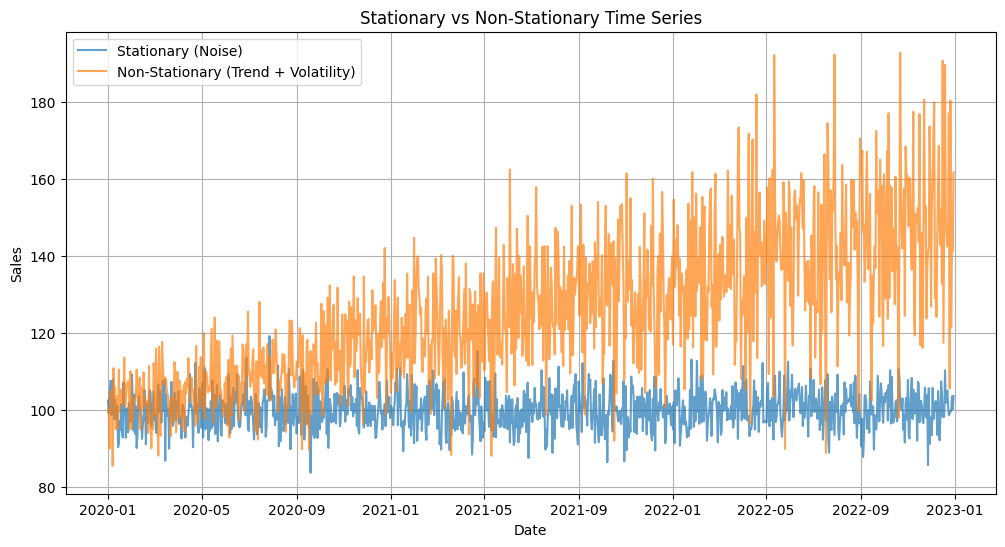

In [51]:
# Plot
plt.figure(figsize=(12, 6))
plt.plot(dates, stationary, label="Stationary (Noise)", alpha=0.7)
plt.plot(dates, non_stationary, label="Non-Stationary (Trend + Volatility)", alpha=0.7)
plt.title("Stationary vs Non-Stationary Time Series")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.show()

# Types of non-stationarity

In [52]:
trend_stationary = 100 + np.linspace(0, 30, n) + np.random.normal(0, 5, n)
variance_stationary = 100 + np.random.normal(0, np.linspace(5, 20, n), n)
seasonal_stationary = 100 + 30 * np.sin(np.linspace(0, 20 * np.pi, n)) + np.random.normal(0, 5, n)
structural_break = np.concatenate([100 + np.random.normal(0, 5, n//2), 80 + np.random.normal(0, 5, (n//2) + 1)])  # Drop after 1.5 years

In [53]:
print(trend_stationary.shape)
print(structural_break.shape)

(1095,)
(1095,)


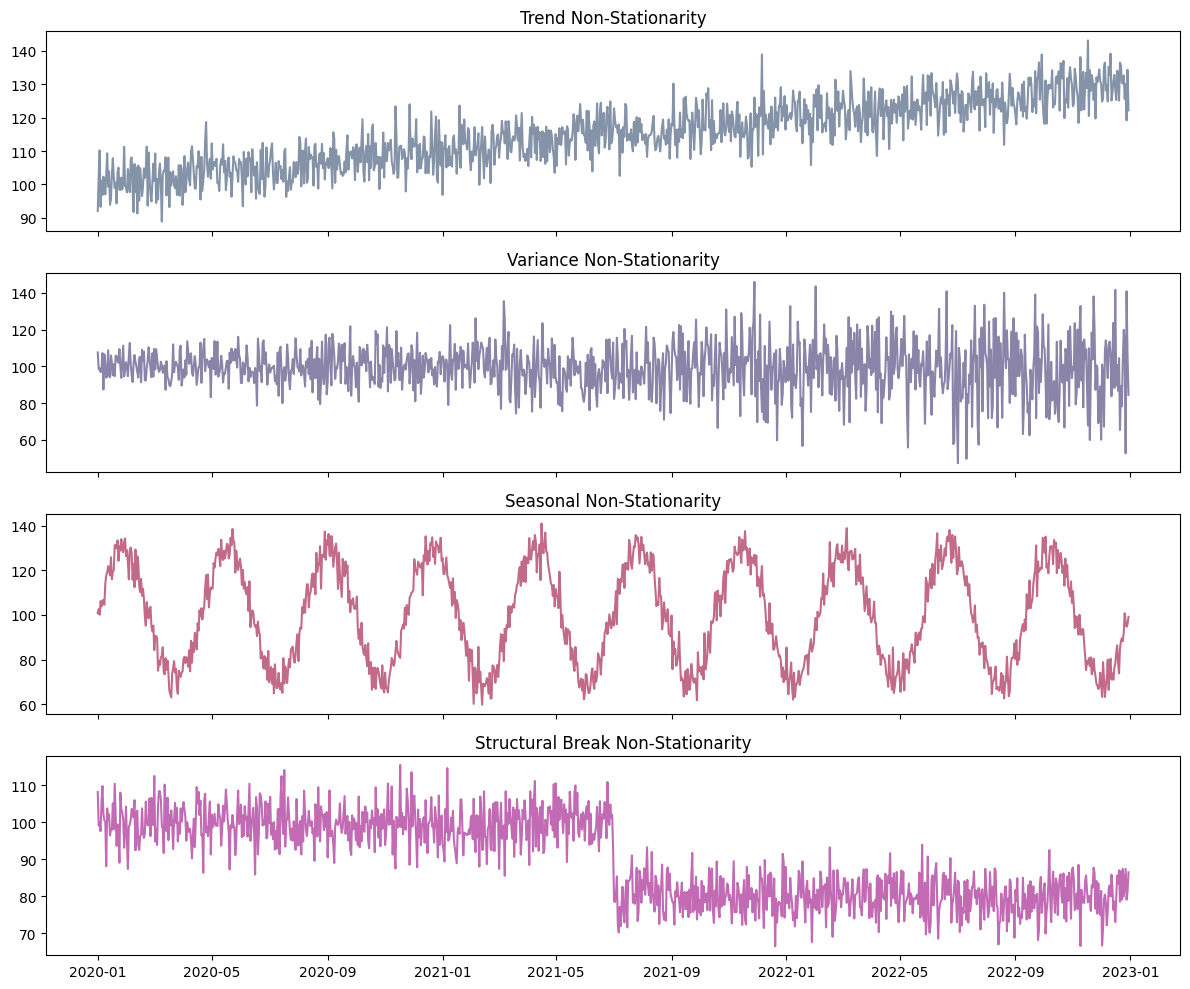

In [54]:
# Plot
fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
axes[0].plot(dates, trend_stationary, label="Trend Non-Stationary", alpha=0.7, color="#526584")
axes[0].set_title("Trend Non-Stationarity")
axes[1].plot(dates, variance_stationary, label="Variance Non-Stationary", alpha=0.7, color="#585284")
axes[1].set_title("Variance Non-Stationarity")
axes[2].plot(dates, seasonal_stationary, label="Seasonal Non-Stationarity", alpha=0.7, color="#A92D56")
axes[2].set_title("Seasonal Non-Stationarity")
axes[3].plot(dates, structural_break, label="Structural Break", alpha=0.7, color="#A92D95")
axes[3].set_title("Structural Break Non-Stationarity")
plt.tight_layout()
plt.show()

# Testing for Stationarity

In [55]:
# ADF Test
def adf_test(series, title=""):
    print(f"ADF test for {title}")
    result = adfuller(series)
    print(f"ADF Statistic: {result[0]}")
    print(f"p-value: {result[1]}")
    print("Critical Values:")
    for key, value in result[4].items():
        print(f"\t{key}: {value}")
    print("\n")

In [56]:
adf_test(stationary, "Stationary Series")
adf_test(non_stationary, "Non-Stationary Series")

ADF test for Stationary Series
ADF Statistic: -33.3976560921828
p-value: 0.0
Critical Values:
	1%: -3.436341508283391
	5%: -2.864185524365606
	10%: -2.5681785627437677


ADF test for Non-Stationary Series
ADF Statistic: -1.1126654106861424
p-value: 0.7099947477125375
Critical Values:
	1%: -3.4364647646486093
	5%: -2.864239892228526
	10%: -2.5682075189699822




In [57]:
# KPSS Test
def kpss_test(series, title=""):
    print(f"KPSS test for {title}")
    result = kpss(series, regression="c")
    print(f"KPSS Statistic: {result[0]}")
    print(f"p-value: {result[1]}")
    print("Critical Values:")
    for key, value in result[3].items():
        print(f"\t{key}: {value}")
    print("\n")

In [58]:
kpss_test(stationary, "Stationary Series")
kpss_test(non_stationary, "Non-Stationary Series")

KPSS test for Stationary Series
KPSS Statistic: 0.3430902295412276
p-value: 0.1
Critical Values:
	10%: 0.347
	5%: 0.463
	2.5%: 0.574
	1%: 0.739


KPSS test for Non-Stationary Series
KPSS Statistic: 5.671794936324666
p-value: 0.01
Critical Values:
	10%: 0.347
	5%: 0.463
	2.5%: 0.574
	1%: 0.739




C:\Users\muham\AppData\Local\Temp\ipykernel_33844\3928175857.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result = kpss(series, regression="c")
C:\Users\muham\AppData\Local\Temp\ipykernel_33844\3928175857.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  result = kpss(series, regression="c")


# Fixing Non-stationarity

### Differencing

In [59]:
# First order differencing
diff_series = non_stationary[1:] - non_stationary[:-1]

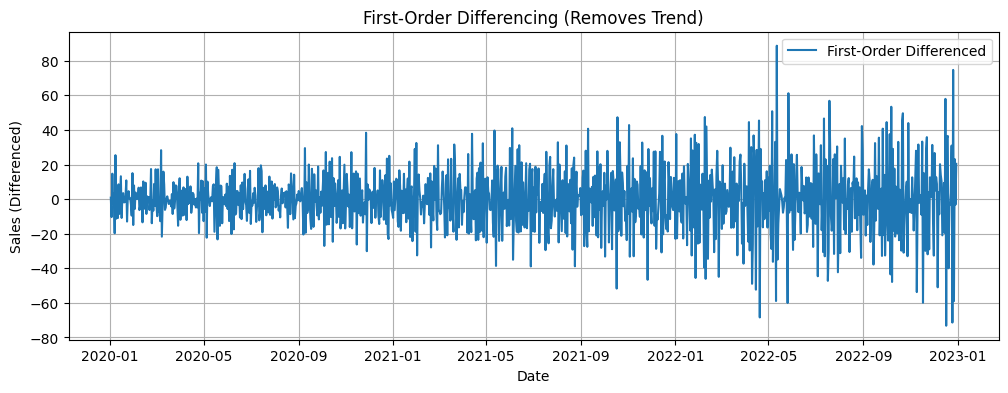

In [60]:
# Plot
plt.figure(figsize=(12, 4))
plt.plot(dates[1:], diff_series, label="First-Order Differenced")
plt.title("First-Order Differencing (Removes Trend)")
plt.xlabel("Date")
plt.ylabel("Sales (Differenced)")
plt.legend()
plt.grid(True)
plt.show()

In [61]:
# ADF Test on differenced series
adf_test(diff_series, "Differenced Series")

ADF test for Differenced Series
ADF Statistic: -12.469173017494876
p-value: 3.273926442324999e-23
Critical Values:
	1%: -3.4364647646486093
	5%: -2.864239892228526
	10%: -2.5682075189699822




In [62]:
# Log transformation
log_series = np.log(non_stationary)

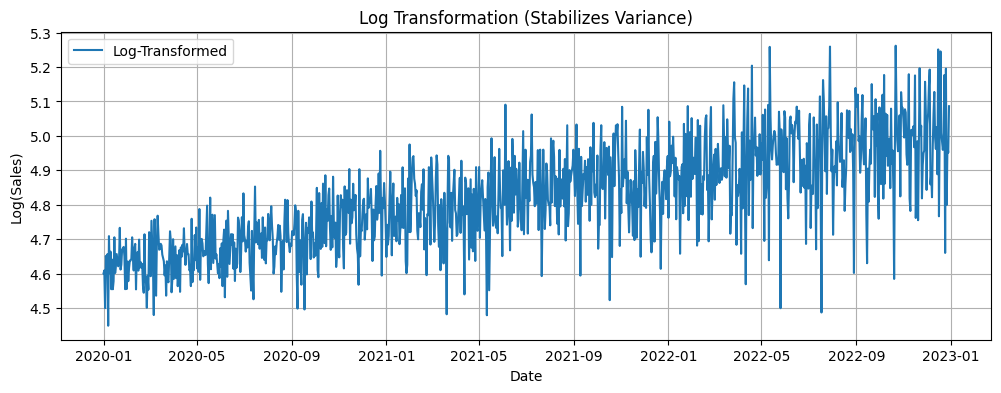

In [63]:
plt.figure(figsize=(12, 4))
plt.plot(dates, log_series, label="Log-Transformed")
plt.title("Log Transformation (Stabilizes Variance)")
plt.xlabel("Date")
plt.ylabel("Log(Sales)")
plt.legend()
plt.grid(True)
plt.show()

In [64]:
adf_test(log_series, "Log-Transformed Series")

ADF test for Log-Transformed Series
ADF Statistic: -1.2482498146117302
p-value: 0.6525033681329395
Critical Values:
	1%: -3.4364647646486093
	5%: -2.864239892228526
	10%: -2.5682075189699822




Log transform alone may not make it stationary (still has a trend).
Combine with differencing

In [65]:
log_diff = log_series[1:] - log_series[:-1]
adf_test(log_diff, "Log + Differenced Series")

ADF test for Log + Differenced Series
ADF Statistic: -12.631749240798225
p-value: 1.49959112245811e-23
Critical Values:
	1%: -3.4364647646486093
	5%: -2.864239892228526
	10%: -2.5682075189699822




In [66]:
# Seasonal differencing (weekly, s=7)
seasonal_diff = non_stationary[7:] - non_stationary[:-7]

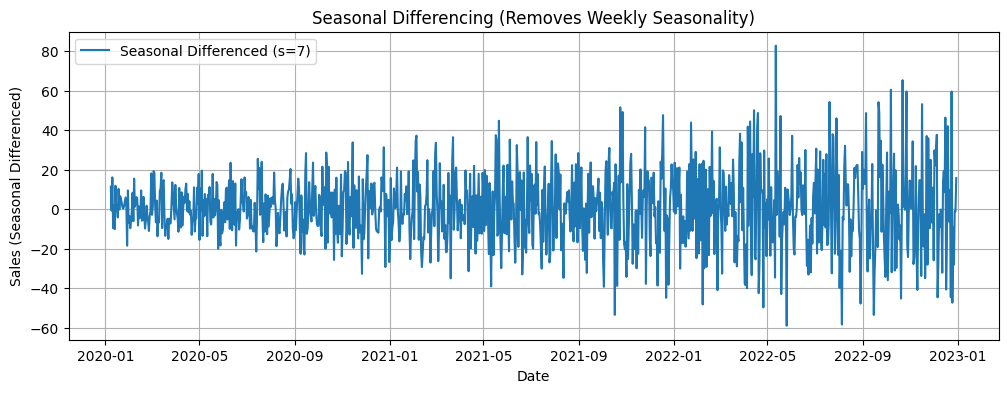

In [67]:
# Plot
plt.figure(figsize=(12, 4))
plt.plot(dates[7:], seasonal_diff, label="Seasonal Differenced (s=7)")
plt.title("Seasonal Differencing (Removes Weekly Seasonality)")
plt.xlabel("Date")
plt.ylabel("Sales (Seasonal Differenced)")
plt.legend()
plt.grid(True)
plt.show()

In [68]:
adf_test(seasonal_diff, "Seasonal Differenced Series")

ADF test for Seasonal Differenced Series
ADF Statistic: -11.973219337974525
p-value: 3.8548606887930867e-22
Critical Values:
	1%: -3.4365050530846846
	5%: -2.864257662806096
	10%: -2.568216983623179


